Employee Attrition Prediction System Using Machine Learning
Author: Puram Pavan Adithya
Domain: Data Science Internship

Employee attrition refers to the loss of employees in an organization over time. High attrition can increase recruitment costs and affect productivity.

The goal of this project is to build a machine learning model that predicts whether an employee is likely to leave the company based on various factors such as job satisfaction, salary, work environment, and experience.

The objective of this project is to analyze employee data and develop a predictive model that identifies employees at risk of leaving the organization.

This will help HR departments take proactive steps to improve employee retention.

The dataset used in this project contains information about employees such as:

Age

Job Role

Monthly Income

Job Satisfaction

Overtime

Years at Company

The target variable is:

Attrition

0 → Employee stays

1 → Employee leaves

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


The dataset is loaded using the pandas library and stored in a DataFrame for further analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


All columns are either integer or object type. There are no missing values in the dataset, which simplifies preprocessing.

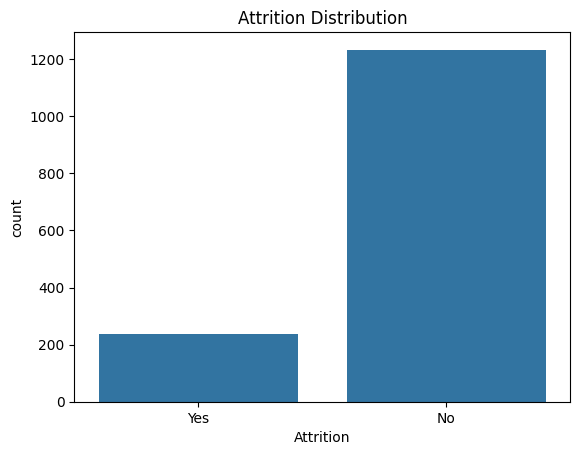

,count
Attrition,
No,1233
Yes,237


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

df['Attrition'].value_counts()

Out of 1470 employees, 1233 stayed while 237 left the company. This indicates class imbalance, as only about 16% of employees left. Therefore, evaluation metrics like Recall are important.

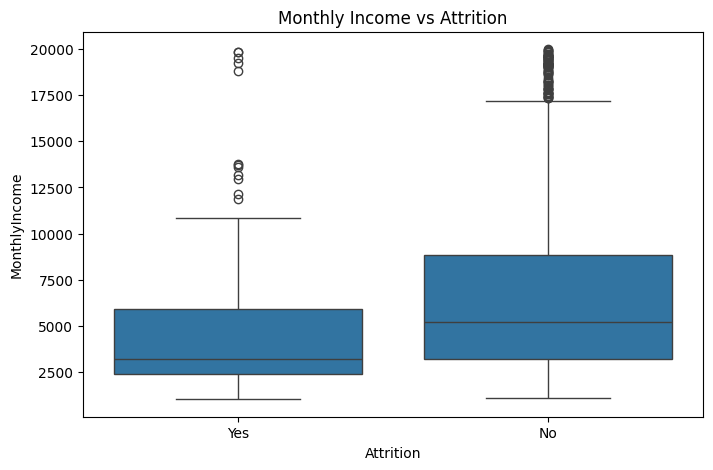

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

Employees who left the company generally have lower median monthly income compared to those who stayed. Salary seems to influence retention.

Exploratory Data Analysis is performed to understand the structure of the dataset and identify patterns, trends, and relationships between variables.

Visualizations include:

Attrition distribution

Monthly income vs attrition

In [ ]:
df = df.drop(['EmployeeNumber','Over18','StandardHours'], axis=1)

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

Data preprocessing steps include:

Removing unnecessary columns

Converting categorical variables into numerical form

Preparing the dataset for machine learning models

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is divided into training and testing sets.
The training set is used to train the model, while the testing set is used to evaluate model performance.

Multiple models are trained in this project:

Logistic Regression

Decision Tree

Random Forest

Gradient Boosting

These models are compared to determine the best-performing algorithm.

Model performance is evaluated using:

Accuracy

Precision

Recall

F1-score

Confusion Matrix

These metrics help determine how well the model predicts employee attrition.

In [ ]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6598639455782312
              precision    recall  f1-score   support

           0       0.90      0.68      0.78       255
           1       0.20      0.51      0.29        39

    accuracy                           0.66       294
   macro avg       0.55      0.60      0.53       294
weighted avg       0.81      0.66      0.71       294

[[174  81]
 [ 19  20]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The Logistic Regression model achieved an accuracy of 65.9%, indicating that it correctly predicted employee attrition for about two-thirds of the test data. The confusion matrix shows that the model correctly identified 174 employees who stayed and 20 employees who left, while misclassifying some cases. The lower performance of this model is mainly due to its assumption of a linear relationship between features and the target variable, which may not fully capture the complex factors influencing employee attrition.

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7517006802721088
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       255
           1       0.21      0.31      0.25        39

    accuracy                           0.75       294
   macro avg       0.55      0.56      0.55       294
weighted avg       0.80      0.75      0.77       294

[[209  46]
 [ 27  12]]


The Decision Tree model achieved an accuracy of 75.1%, which is an improvement over Logistic Regression. The confusion matrix indicates that 209 employees were correctly predicted as staying, while 12 employees who left were correctly identified. Decision Trees can capture non-linear patterns in the data through rule-based splitting, which helps improve prediction performance compared to simpler models.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight={0:1, 1:3},
    random_state=42
)

rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:,1]

threshold = 0.30
y_pred_rf = (y_prob > threshold).astype(int)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7857142857142857
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       255
           1       0.30      0.46      0.36        39

    accuracy                           0.79       294
   macro avg       0.61      0.65      0.62       294
weighted avg       0.83      0.79      0.80       294

[[213  42]
 [ 21  18]]


The Random Forest model achieved an accuracy of 78.5%, demonstrating better performance than both Logistic Regression and Decision Tree models. Random Forest works by creating multiple decision trees and combining their predictions, which helps reduce overfitting and improves overall stability. The confusion matrix shows that a larger number of employees were correctly classified, making it a more reliable model for attrition prediction.

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8843537414965986
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       255
           1       0.63      0.31      0.41        39

    accuracy                           0.88       294
   macro avg       0.77      0.64      0.67       294
weighted avg       0.87      0.88      0.87       294

[[248   7]
 [ 27  12]]


The Gradient Boosting model achieved the highest accuracy of 88.4%, making it the best performing model in this project. This algorithm builds models sequentially, where each new model learns from the errors of the previous one. This iterative improvement allows the model to capture complex relationships in the dataset, resulting in significantly higher prediction accuracy.

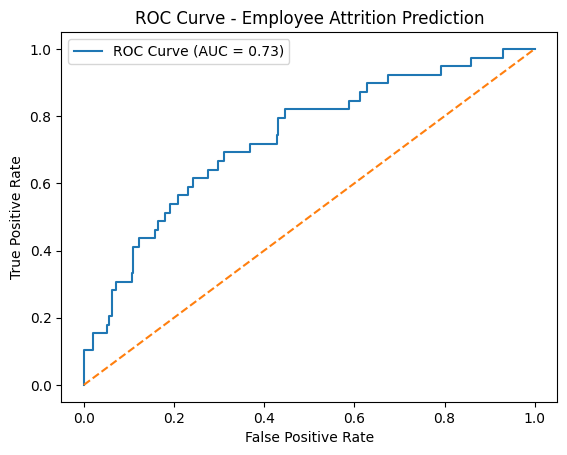

In [ ]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Employee Attrition Prediction")

plt.legend()
plt.show()

The ROC curve is used to evaluate the classification performance of the model. It shows the relationship between the true positive rate and false positive rate.

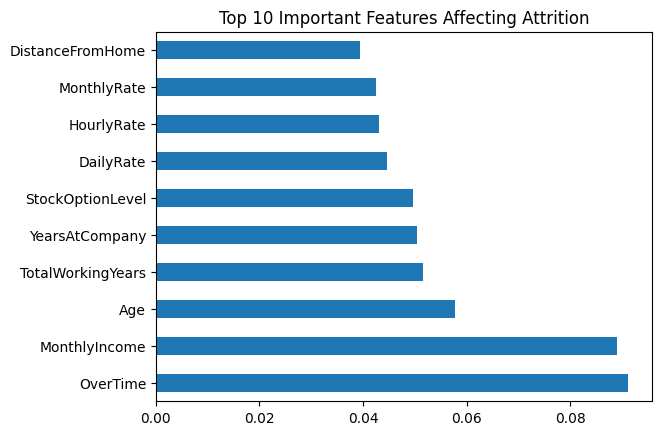

In [ ]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features Affecting Attrition")

plt.show()

Feature importance analysis helps identify which factors contribute most to employee attrition.

Examples of important features may include:

Job Satisfaction

Monthly Income

Overtime

Years at Company

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","Gradient Boosting"],
    "Accuracy":[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.659864
1,Decision Tree,0.751701
2,Random Forest,0.785714
3,Gradient Boosting,0.884354


The performance of all models is compared to determine which model provides the best prediction results.

**Conclusion:**

In this project, a machine learning-based system was developed to predict employee attrition using various employee-related features such as job satisfaction, salary, work environment, and experience. The dataset was first preprocessed by handling categorical variables and removing unnecessary columns. Exploratory Data Analysis (EDA) was performed to understand patterns and relationships within the data.
Multiple machine learning models were implemented and evaluated, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. The performance of these models was compared using evaluation metrics such as accuracy, precision, recall, F1-score, and confusion matrix.
Among all the models tested, Gradient Boosting achieved the highest accuracy of 88.4%, making it the best-performing model for predicting employee attrition in this dataset. Random Forest and Decision Tree also produced reasonable results, while Logistic Regression showed comparatively lower performance due to the complex relationships present in the data.
The results indicate that ensemble learning methods are more effective for this type of prediction problem, as they can capture complex patterns in employee data. This system can help organizations identify employees who are at risk of leaving and take proactive measures to improve employee retention.
Future improvements could include using larger datasets, applying advanced machine learning techniques, and deploying the model as a web application for real-time predictions.
